Imports & Setup

In [28]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import transforms
from utils import *

from model import ImageModel, TextModel, AttentionFusionGarbageClassifier, MultiModalGarbageClassifier
from utils import evaluate, plot_confusion_matrix, plot_roc_auc, build_data_loader


Configuration

In [29]:
# Paths
TEST_DATA_DIR = "garbage_data/CVPR_2024_dataset_Test"
TEST_DATA_DIR_SELF_GATHERED = "garbage_data_self_gathered"
CHECKPOINT_PATH = "saved_model_vit_b_16/best_model_s2.pt"

# Model config (must match training)
IMAGE_BACKBONE = "vit_b_16"
TOKENIZER_NAME = "distilbert-base-uncased"
IMAGE_FEATURE_DIM = 512
TEXT_FEATURE_DIM = 512
BATCH_SIZE = 16
MAX_LEN = 38

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


Load Test Data

In [30]:
test_dataset, test_loader = build_data_loader(
    TEST_DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=0,
    transform_for="test",
    tokenizer_name=TOKENIZER_NAME,
    max_len=MAX_LEN
)

test_dataset_selfgathered, test_loader_selfgathered = build_data_loader(
    TEST_DATA_DIR_SELF_GATHERED,
    batch_size=BATCH_SIZE,
    num_workers=0,
    transform_for="test",
    tokenizer_name=TOKENIZER_NAME,
    max_len=MAX_LEN
)

class_names = list(test_dataset.class_to_idx.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Total test samples:", len(test_dataset))
print("Total test self gathered samples:", len(test_dataset_selfgathered))


Classes: ['Black', 'Blue', 'Green', 'TTR']
Total test samples: 3432
Total test self gathered samples: 66


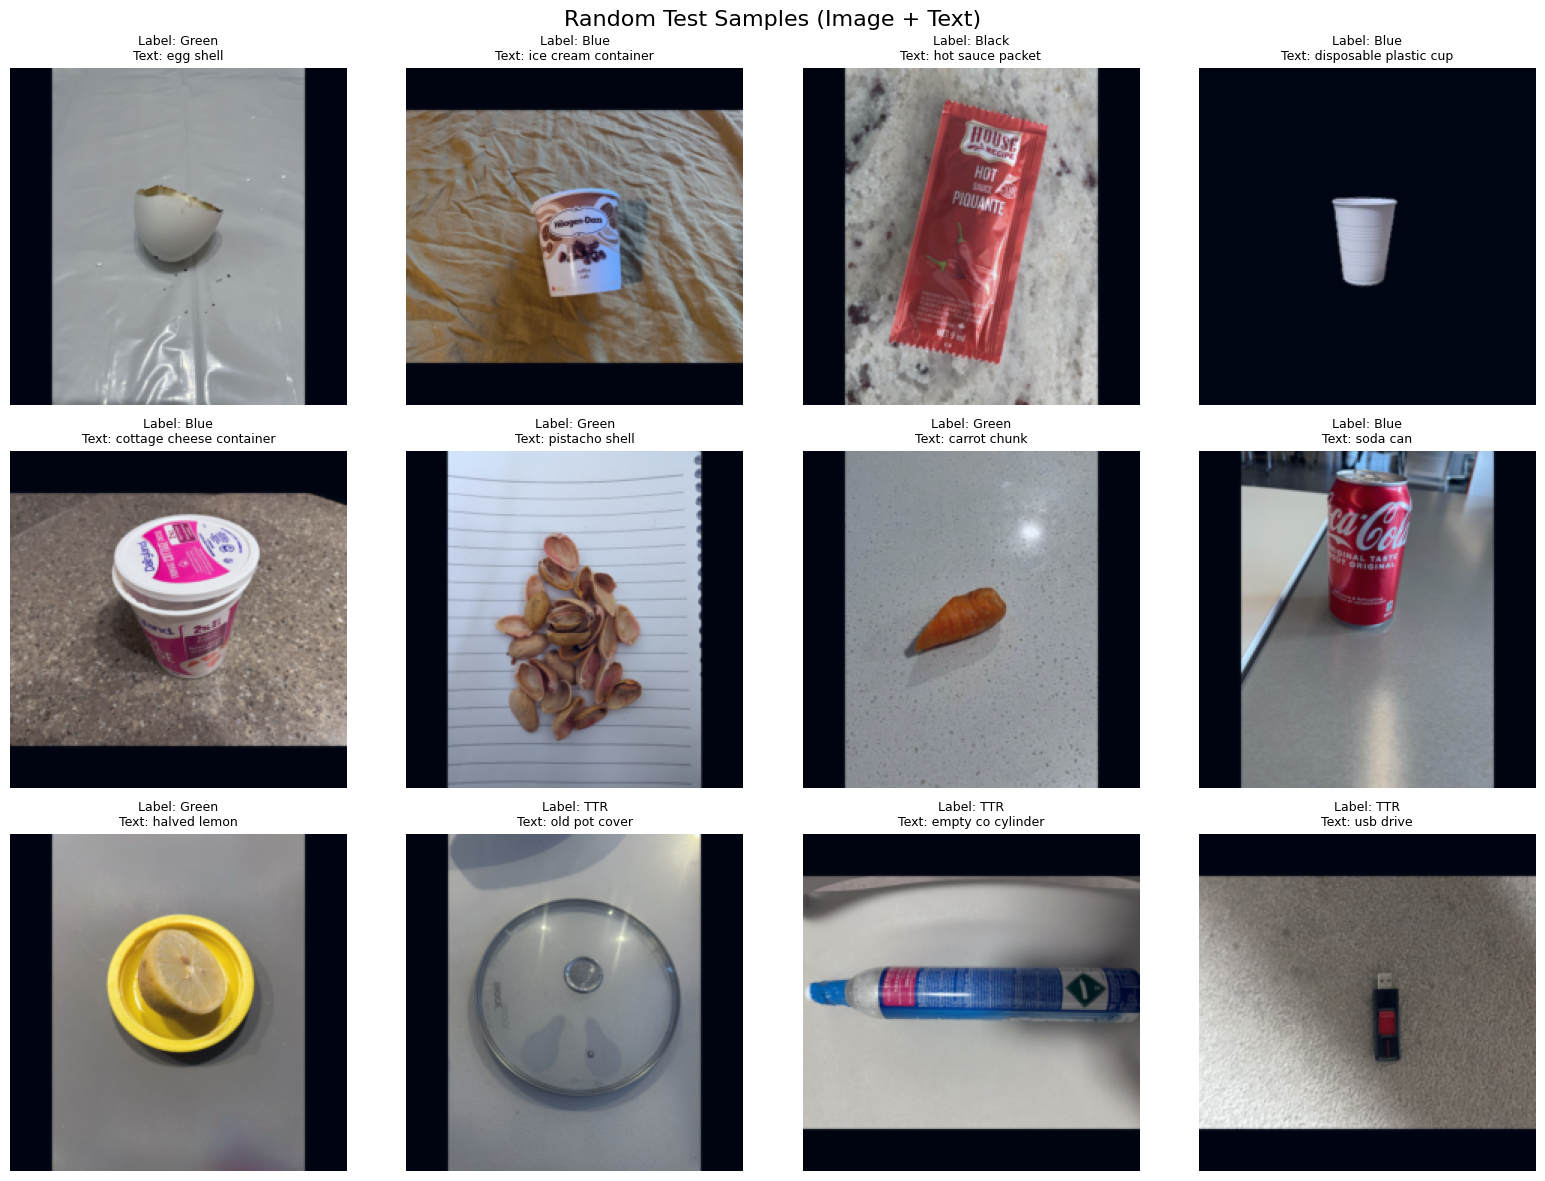

In [31]:
import random
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(dataset, class_names, num_samples=12, seed=None):
    """
    Visualize random samples from a dataset with image, text description, and label.

    Args:
        dataset: PyTorch Dataset (GarbageImageTextDataset)
        class_names: list of class name strings
        num_samples: number of samples to display
        seed: int or None (set for reproducibility)
    """
    if seed is not None:
        random.seed(seed)

    indices = random.sample(range(len(dataset)), num_samples)

    cols = 4
    rows = int(np.ceil(num_samples / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # Image tensor → numpy
        img = sample["image"].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())  # de-normalize for display

        label = class_names[sample["label"]]
        text = sample["text"]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"Label: {label}\nText: {text}",
            fontsize=9
        )

    plt.suptitle("Random Test Samples (Image + Text)", fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_random_samples(test_dataset, class_names, num_samples=12)


Initialize models

In [32]:

image_model = ImageModel(
    backbone_name=IMAGE_BACKBONE,
    feature_dim=IMAGE_FEATURE_DIM,
    trainable=False
).to(DEVICE)

text_model = TextModel(
    model_name=TOKENIZER_NAME,
    feature_dim=TEXT_FEATURE_DIM,
    trainable=False
).to(DEVICE)

fusion_model = MultiModalGarbageClassifier(
    num_classes=num_classes,
    input_image_feature=IMAGE_FEATURE_DIM,
    input_text_feature=TEXT_FEATURE_DIM
).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
image_model.load_state_dict(checkpoint["image_model"])
text_model.load_state_dict(checkpoint["text_model"])
fusion_model.load_state_dict(checkpoint["fusion_model"])

image_model.eval()
text_model.eval()
fusion_model.eval()

print("Model loaded successfully ✅")


ImageModel weight is trainable: False
TextModel weight is trainable: False


C:\Users\mneda\AppData\Local\Temp\ipykernel_3624\3598921170.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE

Model loaded successfully ✅


Run Evaluation

In [33]:
criterion = torch.nn.CrossEntropyLoss()

overall_acc, class_acc, cm, all_labels, all_probs, avg_loss = evaluate(
    image_model,
    text_model,
    fusion_model,
    test_loader,
    DEVICE,
    num_classes,
    criterion
)

preds = np.argmax(all_probs, axis=1)
print(f"Test Accuracy: {overall_acc:.4f}")
print(f"Average Test Loss: {avg_loss:.4f}")


Test Accuracy: 0.8692
Average Test Loss: 0.3758


## Results on test dataset

Classification Report

In [34]:
print(classification_report(
    all_labels,
    preds,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

       Black     0.8189    0.7482    0.7820       695
        Blue     0.8331    0.9190    0.8739      1086
       Green     0.9295    0.9412    0.9353       799
         TTR     0.9025    0.8369    0.8685       852

    accuracy                         0.8692      3432
   macro avg     0.8710    0.8613    0.8649      3432
weighted avg     0.8699    0.8692    0.8682      3432



Confusion Matrix

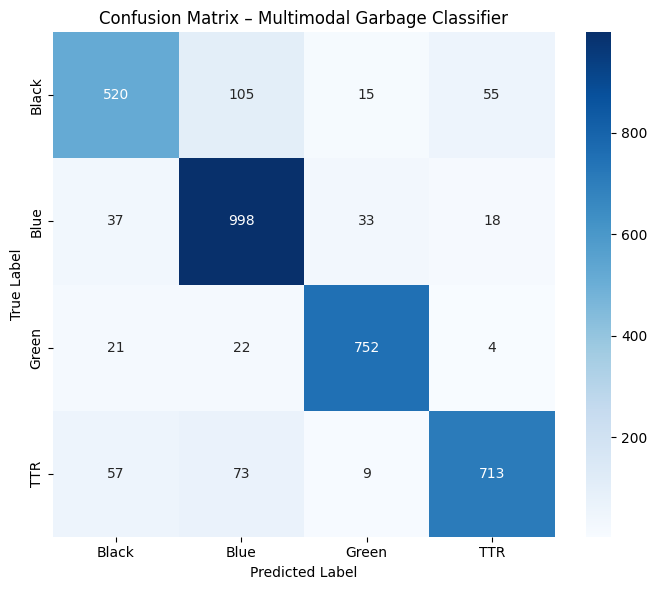

In [35]:
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Multimodal Garbage Classifier")
plt.tight_layout()
plt.show()


ROC–AUC Curves

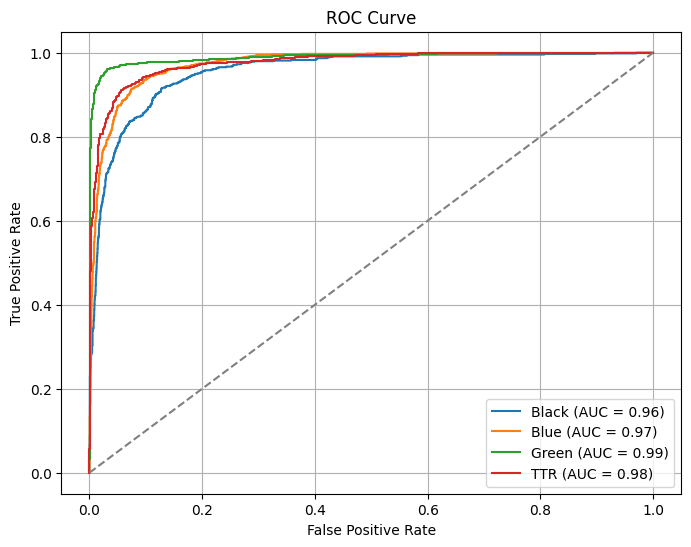

In [36]:
plot_roc_auc(
    all_labels,
    all_probs,
    num_classes,
    class_names,
    save_path="roc_auc.png"
)

from PIL import Image
display(Image.open("roc_auc.png"))


Identify Incorrect Predictions

In [37]:
incorrect_indices = np.where(preds != all_labels)[0]
print(f"Total incorrect predictions: {len(incorrect_indices)}")


Total incorrect predictions: 449


Visualize Incorrect Classifications (Images + Captions)

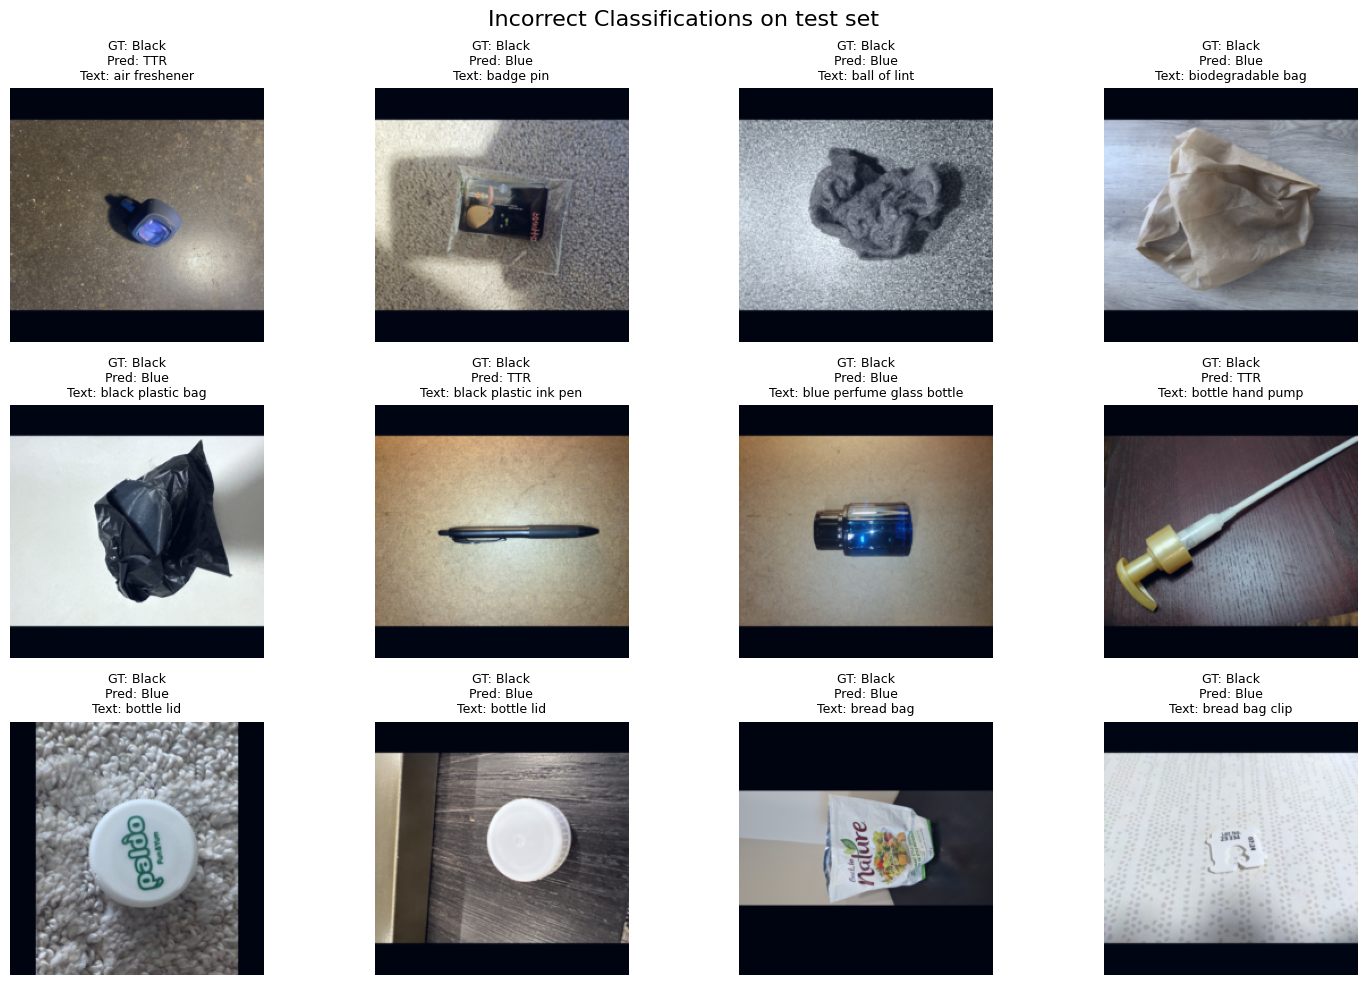

In [38]:
def show_incorrect_samples(dataset, indices, preds, class_names, max_samples=12):
    plt.figure(figsize=(15, 10))
    
    for i, idx in enumerate(indices[:max_samples]):
        sample = dataset[idx]
        img = sample["image"].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        true_label = class_names[sample["label"]]
        pred_label = class_names[preds[idx]]
        caption = sample["text"]

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"GT: {true_label}\nPred: {pred_label}\nText: {caption}",
            fontsize=9
        )

    plt.suptitle("Incorrect Classifications on test set", fontsize=16)
    plt.tight_layout()
    plt.show()

show_incorrect_samples(test_dataset, incorrect_indices, preds, class_names)


Confidence Analysis

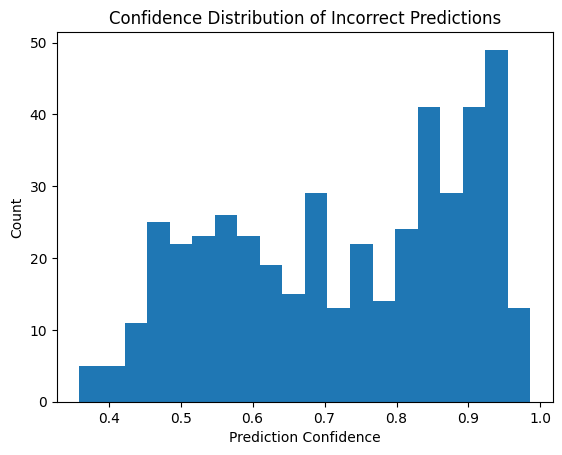

In [39]:
incorrect_probs = all_probs[incorrect_indices]
confidence = np.max(incorrect_probs, axis=1)

plt.hist(confidence, bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution of Incorrect Predictions")
plt.show()


## Results on self-gathered dataset

Classification Report

In [40]:
criterion = torch.nn.CrossEntropyLoss()

overall_acc, class_acc, cm, all_labels, all_probs, avg_loss = evaluate(
    image_model,
    text_model,
    fusion_model,
    test_loader_selfgathered,
    DEVICE,
    num_classes,
    criterion
)

preds = np.argmax(all_probs, axis=1)
print(f"Test Accuracy: {overall_acc:.4f}")
print(f"Average Test Loss: {avg_loss:.4f}")


print(classification_report(
    all_labels,
    preds,
    target_names=class_names,
    digits=4
))


Test Accuracy: 0.9394
Average Test Loss: 0.1666
              precision    recall  f1-score   support

       Black     1.0000    0.8750    0.9333        16
        Blue     0.9000    1.0000    0.9474        18
       Green     0.9412    1.0000    0.9697        16
         TTR     0.9333    0.8750    0.9032        16

    accuracy                         0.9394        66
   macro avg     0.9436    0.9375    0.9384        66
weighted avg     0.9423    0.9394    0.9387        66



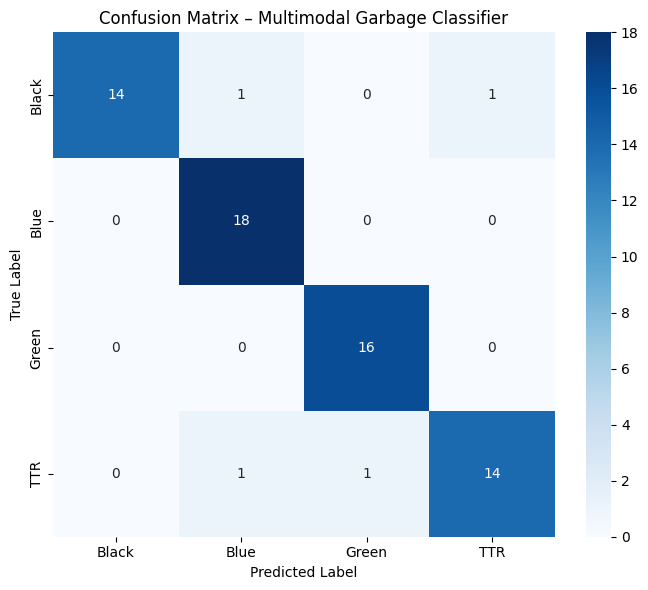

In [41]:
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Multimodal Garbage Classifier")
plt.tight_layout()
plt.show()


ROC–AUC Curves

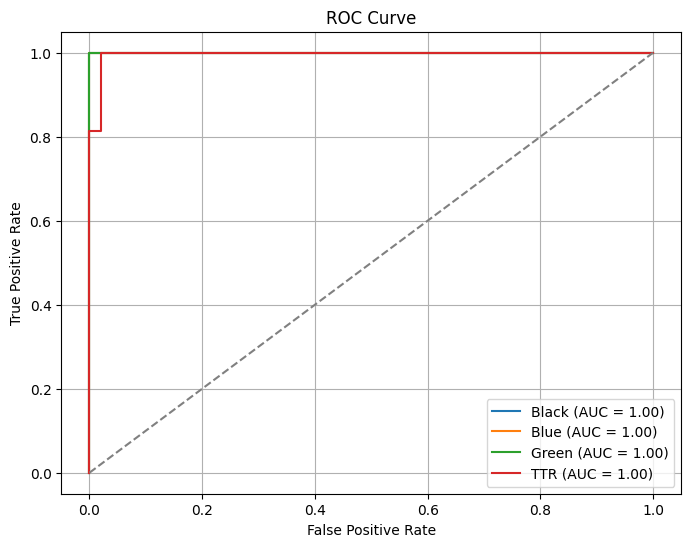

In [42]:
plot_roc_auc(
    all_labels,
    all_probs,
    num_classes,
    class_names,
    save_path="roc_auc.png"
)

from PIL import Image
display(Image.open("roc_auc.png"))


Identify Incorrect Predictions

In [43]:
incorrect_indices = np.where(preds != all_labels)[0]
print(f"Total incorrect predictions: {len(incorrect_indices)}")


Total incorrect predictions: 4


In [44]:
incorrect_indices


array([ 0,  3, 60, 63])

Visualize Incorrect Classifications (Images + Captions)

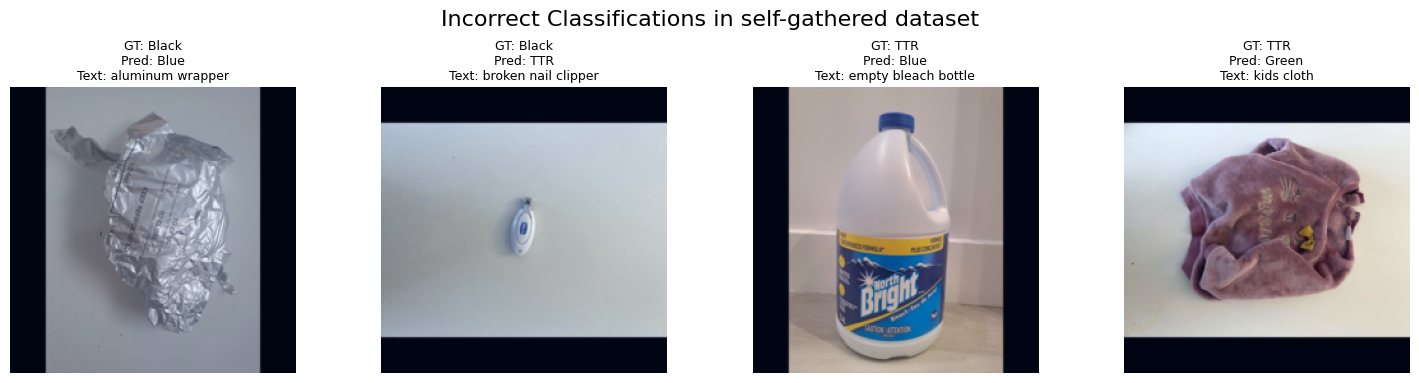

In [45]:
def show_incorrect_samples(dataset, indices, preds, class_names, max_samples=12):
    plt.figure(figsize=(15, 10))
    
    for i, idx in enumerate(indices[:max_samples]):
        sample = dataset[idx]
        img = sample["image"].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        true_label = class_names[sample["label"]]
        pred_label = class_names[preds[idx]]
        caption = sample["text"]

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"GT: {true_label}\nPred: {pred_label}\nText: {caption}",
            fontsize=9
        )

    plt.suptitle("Incorrect Classifications in self-gathered dataset", fontsize=16)
    plt.tight_layout()
    plt.show()

show_incorrect_samples(test_dataset_selfgathered, incorrect_indices, preds, class_names)
